# 1.数据探索及结论

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
import os
import sys


In [3]:
bank = pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-09\2024.9.29\2024.9.29\bank.csv", engine = 'python', encoding='utf_8')
overdue = pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-09\overdue.csv", engine = 'python', encoding='utf_8',index_col=0)
bill = pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-09\bill.csv", engine = 'python', encoding='utf_8')
userinfo = pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-09\userinfo.csv", engine = 'python', encoding='utf_8')
df_list = [userinfo, bank, bill, overdue]

bank.head(), bill.head(), overdue.head(), userinfo.head()

(                        new_user_id        交易时间戳  交易类型       交易金额  工资收入标记  \
 0  65b01fba105ee82613babff7c88929c5  58848407247     1  43.757548       0   
 1  65b01fba105ee82613babff7c88929c5  58849365297     1  42.143743       0   
 2  65b01fba105ee82613babff7c88929c5  58850118237     1  40.189051       0   
 3  65b01fba105ee82613babff7c88929c5  58850118447     1  40.189051       0   
 4  65b01fba105ee82613babff7c88929c5  58850244487     1  40.189051       0   
 
                   交易时间   交易年  交易月  交易日  交易时  交易分  交易秒  
 0  2156-06-25 21:58:44  2156    6   25   21   58   44  
 1  2156-06-27 00:35:29  2156    6   27    0   35   29  
 2  2156-06-27 21:30:23  2156    6   27   21   30   23  
 3  2156-06-27 21:30:44  2156    6   27   21   30   44  
 4  2156-06-28 01:00:48  2156    6   28    1    0   48  ,
                         new_user_id        账单时间戳  银行id     上期账单金额     上期还款金额  \
 0  eddcaa8984f8db5199ec28323efb18a4  59067443637     6  50.622246  50.657612   
 1  eddcaa8984f8db5199ec2

In [4]:
bank

,new_user_id,交易时间戳,交易类型,交易金额,工资收入标记,交易时间,交易年,交易月,交易日,交易时,交易分,交易秒
0,65b01fba105ee82613babff7c88929c5,58848407247,1,43.757548,0,2156-06-25 21:58:44,2156,6,25,21,58,44
1,65b01fba105ee82613babff7c88929c5,58849365297,1,42.143743,0,2156-06-27 00:35:29,2156,6,27,0,35,29
2,65b01fba105ee82613babff7c88929c5,58850118237,1,40.189051,0,2156-06-27 21:30:23,2156,6,27,21,30,23
3,65b01fba105ee82613babff7c88929c5,58850118447,1,40.189051,0,2156-06-27 21:30:44,2156,6,27,21,30,44
4,65b01fba105ee82613babff7c88929c5,58850244487,1,40.189051,0,2156-06-28 01:00:48,2156,6,28,1,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...
1068419,8909c0bd8a030659a64af64874f3a85d,59247918877,1,46.749626,0,2157-10-01 07:31:27,2157,10,1,7,31,27
1068420,8909c0bd8a030659a64af64874f3a85d,59247918877,1,46.313940,0,2157-10-01 07:31:27,2157,10,1,7,31,27
1068421,8909c0bd8a030659a64af64874f3a85d,59247918877,1,46.313940,0,2157-10-01 07:31:27,2157,10,1,7,31,27
1068422,8909c0bd8a030659a64af64874f3a85d,59248782877,0,45.556734,0,2157-10-02 07:31:27,2157,10,2,7,31,27


# 2.数据清洗

In [5]:
for df in df_list:
    print(np.any(df.isnull()))

True
False
False
False


In [6]:
if np.any(userinfo.isnull()):
    print("存在空值")
else:
    print("不存在空值")
# 各列有多少空值
print(userinfo.isnull().sum(axis=0))
# 顶多有 null_number 行是空值
null_number = sum(userinfo.isnull().sum(axis=0))
# 把所有空值的行显示出来
print(userinfo[userinfo.isnull().T.any()].head(null_number))

存在空值
new_user_id    0
性别             0
职业             2
教育程度           0
婚姻状态           1
户口类型           0
dtype: int64
                           new_user_id 性别   职业   教育程度 婚姻状态  户口类型
31    3be79a55ccf09062cdff1b9c684179f9  男  NaN  本科及以上   离异  农业户口
135   b074add6f740af33df4230f28d37a333  男  NaN     大专   离异  家庭户口
5345  9f2e0eb314d821f8d075fbc9e64ce4f5  男   公职     高中  NaN  农业户口


In [7]:
userinfo = userinfo[~userinfo.isnull().T.any()]
userinfo.shape

(9997, 6)

In [8]:
userinfo

,new_user_id,性别,职业,教育程度,婚姻状态,户口类型
0,7259fe272934e0dc348092c37544a445,女,公职,本科及以上,未婚,集体户口
1,0c87f6b1f7e0350a35841ba34df9d26a,男,公职,本科及以上,离异,集体户口
2,74c53a62f15cc039864aefc41170f81b,男,公职,大专,离异,家庭户口
3,211f56f356fa6ecc6334bb73e52c7b16,男,企业,高中,离异,农业户口
4,07b0d9ac7924424894141b2fecfa0ee0,男,公职,本科及以上,已婚,集体户口
...,...,...,...,...,...,...
9995,6b8887024b4258aab9c7b655fd2a718f,男,公职,本科及以上,离异,农业户口
9996,158dd40361cd883d37a30fc448cfa7da,男,公职,大专,未婚,集体户口
9997,12fd60bba16cb55cdf3ca81d7d3326b5,女,公职,本科及以上,离异,其他户口
9998,180232fd2d1db5512be0fe554e58405c,男,企业,大专,未婚,家庭户口


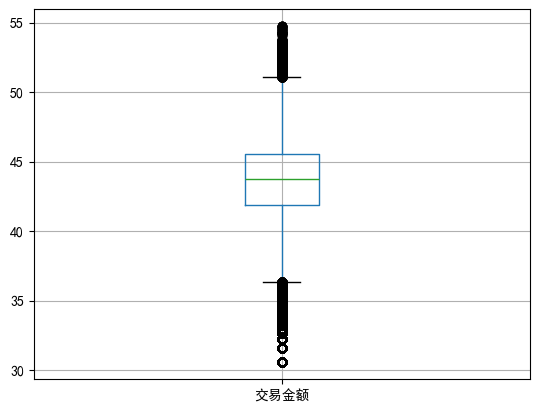

In [9]:
bank.boxplot("交易金额")
plt.show()

首先删掉交易金额小于 0 的数据
交易金额的平均值为：43.415926789739714，标准差为：3.0522622794264396


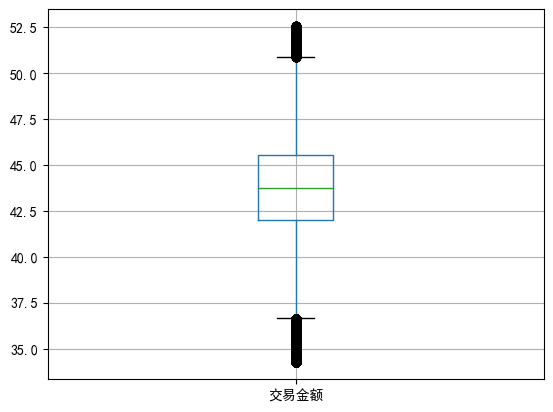

In [10]:
# 删掉交易金额小于 0 的数据
print("首先删掉交易金额小于 0 的数据")
neg_index = bank["交易金额"] < 0
bank = bank[~neg_index]
# 然后对这些数据进行正态分布拟合，求平均值和标准差
avg_val = np.average(bank["交易金额"])
std_val = np.std(bank["交易金额"])
print(f"交易金额的平均值为：{avg_val}，标准差为：{std_val}")
# 基于 3 sigma 原则，删除 [avg - 3 * std, avg + 3 * std] 外的数据
upper_bound = avg_val + 3 * std_val
lower_bound = avg_val - 3 * std_val
drop_index = (bank["交易金额"] < lower_bound) | (bank["交易金额"] > upper_bound)
bank = bank[~drop_index]
# 来看看去异后箱线图
bank.boxplot("交易金额")
plt.show()

# 3.数据预处理 (编码与特征构造)

编码：对 userinfo.csv 中的序数特征进行序号编码，名义特征进行独热编码

In [12]:
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# 独热编码
userinfo0 = pd.get_dummies(userinfo, columns=['性别','职业','婚姻状态','户口类型'],dtype=int)
# 序号编码
userinfo0['教育程度'] = userinfo['教育程度'].map({'未知':0,'初中及以下':1,'高中':2,'大专':3,'本科及以上':4})
userinfo0

,new_user_id,教育程度,性别_女,性别_未知,性别_男,职业_事业单位,职业_企业,职业_公职,职业_学生,职业_无业,...,婚姻状态_其他情况,婚姻状态_已婚,婚姻状态_未婚,婚姻状态_未知,婚姻状态_离异,户口类型_其他户口,户口类型_农业户口,户口类型_家庭户口,户口类型_未知,户口类型_集体户口
0,7259fe272934e0dc348092c37544a445,4,1,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0c87f6b1f7e0350a35841ba34df9d26a,4,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,74c53a62f15cc039864aefc41170f81b,3,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
3,211f56f356fa6ecc6334bb73e52c7b16,2,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,07b0d9ac7924424894141b2fecfa0ee0,4,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,6b8887024b4258aab9c7b655fd2a718f,4,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
9996,158dd40361cd883d37a30fc448cfa7da,3,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
9997,12fd60bba16cb55cdf3ca81d7d3326b5,4,1,0,0,0,0,1,0,0,...,0,0,0,0,1,1,0,0,0,0
9998,180232fd2d1db5512be0fe554e58405c,3,0,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0


状态性特征构造：平均欠款金额、平均还款比率、平均工资收入、平均非工资收入

In [13]:
bill["欠款金额"] = bill["上期账单金额"] - bill["上期还款金额"]
agg_cormoney = bill.groupby("new_user_id")["欠款金额"].agg(["mean"])
agg_cormoney.columns = ["平均欠款金额"]
agg_cormoney.reset_index(inplace=True)
agg_cormoney

,new_user_id,平均欠款金额
0,0000a11bede26d01990cd7bf86a4ffed,1.595222
1,0001102f53f24a8952ed5b47f9564354,-1.647174
2,000228d848615f1320914e0cf6064d12,-24.352021
3,0003f283dfacd7100bba76d876cf94da,-3.289508
4,000fc975cf7a868719446414a5034eae,0.702195
...,...,...
9559,ffe67dcf29be13aaea8203c7e1f78e52,2.522025
9560,ffea401657d40332181dc2b2ef814553,-12.558038
9561,ffeac4580f594e7fc0d98f6ba53755e3,2.659800
9562,ffed832f763c51fe6d055eae506f9ebf,0.733552


In [14]:
bill["还款比例"] = bill["上期账单金额"] / bill["上期还款金额"]
agg_cormoney1 = bill.groupby("new_user_id")["还款比例"].agg(["mean"])
agg_cormoney1.columns = ["平均还款比例"]
agg_cormoney1.reset_index(inplace=True)
agg_cormoney1

,new_user_id,平均还款比例
0,0000a11bede26d01990cd7bf86a4ffed,1.032223
1,0001102f53f24a8952ed5b47f9564354,0.968705
2,000228d848615f1320914e0cf6064d12,0.520719
3,0003f283dfacd7100bba76d876cf94da,0.926490
4,000fc975cf7a868719446414a5034eae,1.014207
...,...,...
9559,ffe67dcf29be13aaea8203c7e1f78e52,1.090502
9560,ffea401657d40332181dc2b2ef814553,0.754112
9561,ffeac4580f594e7fc0d98f6ba53755e3,1.094908
9562,ffed832f763c51fe6d055eae506f9ebf,1.014792


In [15]:
avg_salary = bank[bank['工资收入标记'] == 1].groupby(['new_user_id'])["交易金额"].agg(["mean"])
avg_salary.columns = ["平均工资收入"]
avg_salary.reset_index(inplace=True)
avg_salary

,new_user_id,平均工资收入
0,00375b8a7a62da4f578f4f4464fc4228,44.964550
1,00872649357929f1f3d7fafbe484810b,46.415984
2,00e44c200eeb161df7d08ac1b79bd4a7,47.292812
3,02419b54629f540d3430e6ba8230aac4,45.600048
4,024c12c231362aa4206c001674abe30f,40.380961
...,...,...
549,fdfcea9217eac320f5d2e30a58f356fa,42.958105
550,fe000bc1c6325b6df010187cca665a1e,46.980840
551,fed554907bfead73a15b053ecec59e11,47.292812
552,fee3ee14f7b2e42e86746d19115ef14a,47.061820


In [16]:
avg_income = bank[bank['工资收入标记'] == 0].groupby(['new_user_id'])["交易金额"].agg(["mean"])
avg_income.columns = ["平均非工资收入"]
avg_income.reset_index(inplace=True)
avg_income

,new_user_id,平均非工资收入
0,0003f283dfacd7100bba76d876cf94da,41.896800
1,00284cf15ae27d1ddf4f93922cd7bcb5,46.005739
2,00375b8a7a62da4f578f4f4464fc4228,44.640747
3,0057bbe021e9c3fc79834e3ff126bb98,43.890076
4,00872649357929f1f3d7fafbe484810b,43.472006
...,...,...
1678,ff1d4165c6f00864249193f5e3de1670,43.778847
1679,ff2d236c45aae847d1a1694520fd38f9,42.351222
1680,ff4a7b68f9856efa64c341ada41adb84,45.572454
1681,ffc8a37173c1046de20b0f3b6286cd88,43.149652


趋势性特征构造：过去半年内工资增长趋势

In [17]:
def cust_period(value, op="days", op_period=0, base_dt=None):
    value_list = value.tolist()
    
    while "-1" in value_list:
        value_list.remove("-1")
    if len(value_list) != 0:
        if not base_dt:
            max_dt = max(value_list)
        else:
            max_dt = base_dt

        if op == "years":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(years=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        elif op == "months":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(months=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        elif op == "weeks":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(weeks=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        elif op == "days":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(days=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        else:
            print("Wrong operation unit of time!")
            exit()
        period = list(value.values >= end_dt)
        return period
    else:
        return [True]*len(value.tolist())


In [18]:
agg_agg_6m = bank[bank['工资收入标记'] == 1].groupby("new_user_id")[["交易金额","交易时间"]]
agg_agg_6m = agg_agg_6m.apply(lambda x: x[cust_period(x["交易时间"], "months", 6)])
agg_agg_6m = agg_agg_6m.groupby("new_user_id")["交易金额"].agg(["sum"])
agg_agg_6m.columns = ["6月内工资收入"]
agg_agg_6m.reset_index(inplace=True)
agg_agg_3m = bank[bank['工资收入标记'] == 1].groupby("new_user_id")[["交易金额","交易时间"]]
agg_agg_3m = agg_agg_3m.apply(lambda x: x[cust_period(x["交易时间"], "months", 3)])
agg_agg_3m = agg_agg_3m.groupby("new_user_id")["交易金额"].agg(["sum"])
agg_agg_3m.columns = ["3月内工资收入"]
agg_agg_3m.reset_index(inplace=True)
agg_tend_3m = pd.merge(agg_agg_6m, agg_agg_3m, how='left', on=['new_user_id'])
agg_tend_3m["半年到3月前工资收入"] = agg_tend_3m["6月内工资收入"] - agg_tend_3m['3月内工资收入']
def cal(x):
    if x['3月内工资收入'] >= x['半年到3月前工资收入']:
        return 1
    return 0
agg_tend_3m["过去半年内工资增长趋势"] = agg_tend_3m.apply(cal, axis=1)
agg_tend_3m

,new_user_id,6月内工资收入,3月内工资收入,半年到3月前工资收入,过去半年内工资增长趋势
0,00375b8a7a62da4f578f4f4464fc4228,179.858202,179.858202,0.000000,1
1,00872649357929f1f3d7fafbe484810b,232.079920,232.079920,0.000000,1
2,00e44c200eeb161df7d08ac1b79bd4a7,47.292812,47.292812,0.000000,1
3,02419b54629f540d3430e6ba8230aac4,723.807150,505.340387,218.466763,1
4,024c12c231362aa4206c001674abe30f,444.190576,240.997538,203.193037,1
...,...,...,...,...,...
549,fdfcea9217eac320f5d2e30a58f356fa,85.916210,85.916210,0.000000,1
550,fe000bc1c6325b6df010187cca665a1e,330.371292,187.340330,143.030962,1
551,fed554907bfead73a15b053ecec59e11,94.585625,94.585625,0.000000,1
552,fee3ee14f7b2e42e86746d19115ef14a,329.726555,235.289386,94.437169,1


统计性特征构造：过去半年内收入波动、交易行为的聚类特征

In [19]:
# 过去半年内收入波动
# 交易类型是 0 的为收入，1 是支出
in_train = bank[bank['交易类型'] == 1]
# 以月为单位统计标准差
agg_agg_tot = in_train.groupby("new_user_id")[['new_user_id']].agg('count')
agg_agg_tot.columns = ['None']
agg_agg_tot.reset_index(inplace=True)
agg_agg_tot = agg_agg_tot[['new_user_id']]
for i in range(1, 7):
    agg_agg_ins = in_train.groupby("new_user_id")[["交易金额","交易时间"]]
    agg_agg_ins = agg_agg_ins .apply(lambda x: x[cust_period(x["交易时间"], "months", i)])
    agg_agg_ins = agg_agg_ins.groupby("new_user_id")["交易金额"].agg(["sum"])
    agg_agg_ins.columns = [f"{i}月内收入"]
    agg_agg_ins.reset_index(inplace=True)
    agg_agg_tot = pd.merge(agg_agg_tot, agg_agg_ins, how='left', on=['new_user_id'])
for i in range(2, 7):
    agg_agg_tot[f'{i-1}到{i}月收入'] = agg_agg_tot[f"{i}月内收入"] - agg_agg_tot[f"{i-1}月内收入"]
agg_agg_tot[f'{0}到{1}月收入'] = agg_agg_tot[f"{1}月内收入"]
cols = [f'{i-1}到{i}月收入' for i in range(1, 7)]
agg_agg_tot['过去半年内收入波动'] = agg_agg_tot.apply(lambda x: np.std([x[c] for c in cols]), axis=1)
agg_agg_tot

,new_user_id,1月内收入,2月内收入,3月内收入,4月内收入,5月内收入,6月内收入,1到2月收入,2到3月收入,3到4月收入,4到5月收入,5到6月收入,0到1月收入,过去半年内收入波动
0,0003f283dfacd7100bba76d876cf94da,1370.029320,2077.131122,2409.089923,3188.894728,4111.918439,4570.785390,707.101802,331.958801,779.804805,923.023711,458.866951,1370.029320,335.604913
1,00284cf15ae27d1ddf4f93922cd7bcb5,12234.159757,23108.637713,40589.155590,60455.111834,60455.111834,60455.111834,10874.477957,17480.517877,19865.956244,0.000000,0.000000,12234.159757,7735.382997
2,00375b8a7a62da4f578f4f4464fc4228,6791.505674,9954.923321,9954.923321,10772.738636,10772.738636,11216.671980,3163.417647,0.000000,817.815315,0.000000,443.933344,6791.505674,2450.466084
3,0057bbe021e9c3fc79834e3ff126bb98,1131.440292,1836.303262,3327.108790,5238.269238,6419.212381,7321.210754,704.862970,1490.805528,1911.160448,1180.943143,901.998373,1131.440292,393.043172
4,00872649357929f1f3d7fafbe484810b,664.916185,1321.637488,1536.418315,1619.892389,1917.798447,1958.840734,656.721302,214.780827,83.474075,297.906057,41.042287,664.916185,250.804742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,ff1d4165c6f00864249193f5e3de1670,1834.708723,3065.651284,4760.137609,6007.137549,7359.088139,9265.644361,1230.942561,1694.486324,1246.999941,1351.950590,1906.556223,1834.708723,277.399000
1679,ff2d236c45aae847d1a1694520fd38f9,3486.877871,7369.729982,11648.963986,13747.163124,16880.385850,18645.966735,3882.852111,4279.234004,2098.199138,3133.222726,1765.580885,3486.877871,907.207775
1680,ff4a7b68f9856efa64c341ada41adb84,6323.172494,10831.302726,15530.609416,20212.676227,25161.096200,28906.102465,4508.130232,4699.306691,4682.066811,4948.419973,3745.006265,6323.172494,770.546751
1681,ffc8a37173c1046de20b0f3b6286cd88,5425.656374,7615.424959,11591.826976,19758.078976,25802.873100,28882.859547,2189.768585,3976.402016,8166.252000,6044.794123,3079.986448,5425.656374,1988.363433


In [17]:
# 交易行为的聚类特征
agg_agg_behavior = bank.groupby(["new_user_id", "交易类型"])["交易金额"].agg(["max", "min", "mean", "count", "sum"])
agg_agg_behavior.reset_index(inplace=True)
agg_agg_behavior_1 = agg_agg_behavior[agg_agg_behavior['交易类型']==1][["new_user_id", "max", "min", "mean", "count", "sum"]]
agg_agg_behavior_0 = agg_agg_behavior[agg_agg_behavior['交易类型']==0][["new_user_id", "max", "min", "mean", "count", "sum"]]
agg_agg_behavior_0.columns = ["new_user_id", "交易类型_0_交易金额_max", "交易类型_0_交易金额_min", "交易类型_0_交易金额_mean", "交易类型_0_交易金额_count", "交易类型_0_交易金额_sum"]
agg_agg_behavior_1.columns = ["new_user_id", "交易类型_1_交易金额_max", "交易类型_1_交易金额_min", "交易类型_1_交易金额_mean", "交易类型_1_交易金额_count", "交易类型_1_交易金额_sum"]
agg_agg_behavior_0,agg_agg_behavior_1

(                           new_user_id  交易类型_0_交易金额_max  交易类型_0_交易金额_min  \
 0     0003f283dfacd7100bba76d876cf94da        48.266228        35.308421   
 2     00284cf15ae27d1ddf4f93922cd7bcb5        49.442433        38.192380   
 4     00375b8a7a62da4f578f4f4464fc4228        50.060691        37.202054   
 6     0057bbe021e9c3fc79834e3ff126bb98        48.020046        36.128595   
 8     00872649357929f1f3d7fafbe484810b        47.502580        35.363689   
 ...                                ...              ...              ...   
 3355  ff1d4165c6f00864249193f5e3de1670        49.150646        36.500781   
 3357  ff2d236c45aae847d1a1694520fd38f9        48.736429        36.931687   
 3359  ff4a7b68f9856efa64c341ada41adb84        51.355072        36.217599   
 3361  ffc8a37173c1046de20b0f3b6286cd88        47.647217        35.965628   
 3363  ffea401657d40332181dc2b2ef814553        49.667581        34.375590   
 
       交易类型_0_交易金额_mean  交易类型_0_交易金额_count  交易类型_0_交易金额_sum  
 0          

通过逻辑回归（为了方便排版，移至分类模型处）选择最优特征进行训练

In [26]:
# 构造特征
df = pd.merge(userinfo0, overdue, on='new_user_id', how='left')
print(df.shape)
df = pd.merge(df, agg_cormoney, on='new_user_id', how='left')
df = pd.merge(df, agg_cormoney1, on='new_user_id', how='left')
df = pd.merge(df, avg_salary, on='new_user_id', how='left')
df = pd.merge(df, avg_income, on='new_user_id', how='left')
df = pd.merge(df, agg_tend_3m[['new_user_id', '过去半年内工资增长趋势']], on='new_user_id', how='left')
df = pd.merge(df, agg_agg_tot[['new_user_id', '过去半年内收入波动']], on='new_user_id', how='left')
df = pd.merge(df, agg_agg_behavior_0, on='new_user_id', how='left')
df = pd.merge(df, agg_agg_behavior_1, on='new_user_id', how='left')

# 转换分类型（Categorical）数据为对象（object）类型
for column in df.columns:
    if pd.api.types.is_categorical_dtype(df[column]):
        df[column] = df[column].astype('object')

# 填补空值
df = df.fillna(0)

df
print(df.shape)

(9997, 24)
(9997, 40)


In [19]:
# 定义特征列表
feat_0 = ['教育程度', '婚姻状态_已婚', '婚姻状态_未婚', '户口类型_农业户口', '户口类型_集体户口']
feat_1=['平均欠款金额','平均还款比例','平均工资收入','平均非工资收入']
feat_2=['过去半年内工资增长趋势','过去半年内收入波动']
feat_3=['交易类型_0_交易金额_mean','交易类型_1_交易金额_mean']
# 准备训练和测试数据
X = df[feat_0+feat_1+feat_2+feat_3]
Y_reg = df['分数']  # 回归标签
Y_clf = df['标签']  # 分类标签

# 划分数据集
X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X, Y_reg, test_size=0.2,random_state=100)
X_train_clf, X_test_clf, Y_train_clf, Y_test_clf = train_test_split(X, Y_clf, test_size=0.2,random_state=100)

# 4.回归模型

In [20]:
# 岭回归的超参数网格
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
#ridge = Ridge(max_iter=10000)
ridge = Ridge()
grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5)
grid_search_ridge.fit(X_train_reg, Y_train_reg)

# Lasso回归的超参数网格
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso = Lasso(max_iter=1000000)
grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5)
grid_search_lasso.fit(X_train_reg, Y_train_reg)
 
# 打印最佳参数
print("岭回归最佳参数：", grid_search_ridge.best_params_)
print("Lasso回归最佳参数：", grid_search_lasso.best_params_)

岭回归最佳参数： {'alpha': 10}
Lasso回归最佳参数： {'alpha': 0.001}


In [21]:
# 1. 线性回归模型
model_linear = LinearRegression()
model_linear.fit(X_train_reg, Y_train_reg)
Y_pred_linear = model_linear.predict(X_test_reg)
mse_linear = mean_squared_error(Y_test_reg, Y_pred_linear)
r_squre_linear = r2_score(Y_test_reg, Y_pred_linear)
print('线性回归模型的MSE:', mse_linear)
print('线性回归模型的R方:', r_squre_linear)

# 2. 岭回归模型
model_ridge = Ridge(alpha=10)
model_ridge.fit(X_train_reg, Y_train_reg)
Y_pred_ridge = model_ridge.predict(X_test_reg)
mse_ridge = mean_squared_error(Y_test_reg, Y_pred_ridge)
r_squre_ridge = r2_score(Y_test_reg, Y_pred_ridge)
print('岭回归模型的MSE:', mse_ridge)
print('岭回归模型的R方:', r_squre_ridge)

# 3. Lasso回归模型
model_lasso = Lasso(alpha=0.001, max_iter=1000000)
model_lasso.fit(X_train_reg, Y_train_reg)
Y_pred_lasso = model_lasso.predict(X_test_reg)
mse_lasso = mean_squared_error(Y_test_reg, Y_pred_lasso)
r_squre_lasso = r2_score(Y_test_reg, Y_pred_lasso)
print('Lasso回归模型的MSE:', mse_lasso)
print('Lasso回归模型的R方:', r_squre_lasso)

线性回归模型的MSE: 7.029845022304273
线性回归模型的R方: 0.894707260199194
岭回归模型的MSE: 7.027578910346763
岭回归模型的R方: 0.8947412019341745
Lasso回归模型的MSE: 7.031131843427914
Lasso回归模型的R方: 0.8946879862434649


# 5.分类模型

In [22]:
# 逻辑回归的超参数网格
param_grid_logistic = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
logistic = LogisticRegression()
grid_search_logistic = GridSearchCV(logistic, param_grid_logistic, cv=5)
grid_search_logistic.fit(X_train_clf, Y_train_clf)
print("逻辑回归最佳参数：", grid_search_logistic.best_params_)

C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  FitFailedWarning)
C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
AttributeError: 'str' object has no attribute 'decode'

  FitFailedWarning)
C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
AttributeError: 'str' object has no attribute 'decode'

  FitFailedWarning)
C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitF

C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
AttributeError: 'str' object has no attribute 'decode'

  FitFailedWarning)
C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
AttributeError: 'str' object has no attribute 'decode'

  FitFailedWarning)
C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  FitFailedWarning)
C:\Users\lenovo\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitF

ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

In [ ]:
# 分类模型
# 1. 逻辑回归
model_clf = LogisticRegression(C= 0.001, penalty='l2')
model_clf.fit(X_train_clf, Y_train_clf)
Y_pred_clf = model_clf.predict(X_test_clf)
f1 = f1_score(Y_test_clf, Y_pred_clf)
print('分类模型的F1分数为：', f1)

# 绘制ROC曲线
Y_pred = model_clf.predict_proba(X_test_clf)[:, 1]  # 各个测试样本 softmax ，用于计算 roc
Y_pred_lab = model_clf.predict(X_test_clf)
fpr, tpr, thresholds = roc_curve(Y_test_clf, Y_pred)
roc_auc = auc(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.title(f'''auc:{roc_auc :.3f}, f1 socre:{f1_score(Y_test_clf, Y_pred_lab) :.3f}, accuracy :{accuracy_score(Y_test_clf, Y_pred_lab) :.3f}, 
recall:{recall_score(Y_test_clf, Y_pred_lab) :.3f}, precision:{precision_score(Y_test_clf, Y_pred_lab) :.3f}''')
plt.show()


In [ ]:
#SVC高斯核超参数网格
C=[0.05,0.5,1]
parameters = {'C':C}

grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid=parameters, cv=5, verbose =1)
grid_search.fit(X_train_clf, Y_train_clf)
best_C = grid_search.best_params_['C']
best_accuracy = grid_search.best_score_

best_C, best_accuracy

In [ ]:
# AdaBoost的超参数网格
param_grid_ada = {
    'learning_rate': [0.01, 0.1, 1],
    'n_estimators': [50, 100, 200]
}
ada = AdaBoostClassifier()
grid_search_ada = GridSearchCV(ada, param_grid_ada, cv=5)
grid_search_ada.fit(X_train_clf, Y_train_clf)
print("AdaBoost最佳参数：", grid_search_ada.best_params_)

In [ ]:
# 用随机搜索法确定 随机森林的超参数
param_dist_rf = {
    'n_estimators': np.arange(10, 200, 10),
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 10, 1),
    'min_samples_leaf': np.arange(1, 10, 1)
}

# 创建随机森林分类器实例
rf = RandomForestClassifier()

# 随机搜索实例
random_search_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf, n_iter=100, cv=5, random_state=42)
random_search_rf.fit(X_train_clf, Y_train_clf)
print("随机森林分类器的最佳参数：", random_search_rf.best_params_)

In [ ]:
# 分类模型
# 2. 随机森林分类器
rf_model = RandomForestClassifier(n_estimators=100,min_samples_split= 5, min_samples_leaf= 9, max_features= 'log2', max_depth= 30)
rf_model.fit(X_train_clf, Y_train_clf)
rf_pred = rf_model.predict(X_test_clf)
rf_accuracy = accuracy_score(Y_test_clf, rf_pred)
rf_f1 = f1_score(Y_test_clf, rf_pred)
print('随机森林准确率:', rf_accuracy)
print('随机森林F1分数:', rf_f1)

# 3. 支持向量机
svc_model = SVC(C=1,kernel='rbf')
svc_model.fit(X_train_clf, Y_train_clf)
svc_pred = svc_model.predict(X_test_clf)
svc_accuracy = accuracy_score(Y_test_clf, svc_pred)
svc_f1 = f1_score(Y_test_clf, svc_pred)
print('支持向量机准确率:', svc_accuracy)
print('支持向量机F1分数:', svc_f1)

# 4. AdaBoost分类器
ada_model = AdaBoostClassifier(learning_rate= 0.01, n_estimators= 50)
ada_model.fit(X_train_clf, Y_train_clf)
ada_pred = ada_model.predict(X_test_clf)
ada_accuracy = accuracy_score(Y_test_clf, ada_pred)
ada_f1 = f1_score(Y_test_clf, ada_pred)
print('AdaBoost分类器准确率:', ada_accuracy)
print('AdaBoost分类器F1分数:', ada_f1)

# 5. 线性判别分析（LDA）
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_clf, Y_train_clf)
lda_pred = lda_model.predict(X_test_clf)
lda_accuracy = accuracy_score(Y_test_clf, lda_pred)
lda_f1 = f1_score(Y_test_clf, lda_pred)
print('线性判别分析准确率:', lda_accuracy)
print('线性判别分析F1分数:', lda_f1)

In [ ]:
Y_pred = rf_model.predict_proba(X_test_clf)[:, 1]  # 各个测试样本 softmax ，用于计算 roc
Y_pred_lab = rf_model.predict(X_test_clf)
fpr, tpr, thresholds = roc_curve(Y_test_clf, Y_pred)
roc_auc = auc(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.title(f'''随机森林  auc:{roc_auc :.3f}, f1 socre:{f1_score(Y_test_clf, Y_pred_lab) :.3f},
accuracy :{accuracy_score(Y_test_clf, Y_pred_lab) :.3f}, recall:{recall_score(Y_test_clf, Y_pred_lab) :.3f}, precision:{precision_score(Y_test_clf, Y_pred_lab) :.3f}''')
plt.show()

In [ ]:
Y_pred = ada_model.predict_proba(X_test_clf)[:, 1]  # 各个测试样本 softmax ，用于计算 roc
Y_pred_lab = ada_model.predict(X_test_clf)
fpr, tpr, thresholds = roc_curve(Y_test_clf, Y_pred)
roc_auc = auc(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.title(f'''AdaBoost  auc:{roc_auc :.3f}, f1 socre:{f1_score(Y_test_clf, Y_pred_lab) :.3f},
accuracy :{accuracy_score(Y_test_clf, Y_pred_lab) :.3f}, recall:{recall_score(Y_test_clf, Y_pred_lab) :.3f}, precision:{precision_score(Y_test_clf, Y_pred_lab) :.3f}''')
plt.show()

In [ ]:
Y_pred = lda_model.predict_proba(X_test_clf)[:, 1]  # 各个测试样本 softmax ，用于计算 roc
Y_pred_lab = lda_model.predict(X_test_clf)
fpr, tpr, thresholds = roc_curve(Y_test_clf, Y_pred)
roc_auc = auc(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.title(f'''线性判别分析  auc:{roc_auc :.3f}, f1 socre:{f1_score(Y_test_clf, Y_pred_lab) :.3f},
accuracy :{accuracy_score(Y_test_clf, Y_pred_lab) :.3f}, recall:{recall_score(Y_test_clf, Y_pred_lab) :.3f}, precision:{precision_score(Y_test_clf, Y_pred_lab) :.3f}''')
plt.show()